Section 1: Preprocessing
Currently only one edf file per dataset is used due to the large size of the datasets
This will be scaled up for the next milestone

Imports and the file paths

In [1]:
import mne
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

mne.set_log_level("WARNING")

# File paths
chb_path = "data/chbmit/chb01/chb01_01.edf"
siena_path = "data/siena/PN00/PN00-1.edf"

Loads the edf files, along with their sample rate and number of channels

In [2]:
raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
raw_siena = mne.io.read_raw_edf(siena_path, preload=False, verbose=False)

print("CHB sampling rate:", raw_chb.info["sfreq"])
print("CHB number of channels:", len(raw_chb.ch_names))

print("Siena sampling rate:", raw_siena.info["sfreq"])
print("Siena number of channels:", len(raw_siena.ch_names))

CHB sampling rate: 256.0
CHB number of channels: 23
Siena sampling rate: 512.0
Siena number of channels: 35


C:\Users\arnol\AppData\Local\Temp\ipykernel_39636\2310033075.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
C:\Users\arnol\AppData\Local\Temp\ipykernel_39636\2310033075.py:1: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_chb = mne.io.read_raw_edf(chb_path, preload=False, verbose=False)
C:\Users\arnol\AppData\Local\Temp\ipykernel_39636\2310033075.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw_siena = mne.io.read_raw_edf(siena_path, preload=False, verbose=False)
C:\Users\arnol\AppData\Local\Temp\ipykernel_39636\2310033075.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw_siena = mne.io.read_raw

# Methods for preprocessing the data

In [3]:
def drop_mne_duplicates(raw):
    to_drop = [ch for ch in raw.ch_names if ch.endswith("-1")]
    if to_drop:
        raw.drop_channels(to_drop)

def preprocess_eeg(raw, dataset_name, target_sfreq=256):
    raw = raw.copy()
    raw.load_data()

    # Drop obvious non-EEG channels
    non_eeg_keywords = ["EKG", "ECG", "SPO2", "HR", "PHOTIC", "IBI", "BURSTS", "SUPPR", "MK"]
    drop_now = []

    for ch in raw.ch_names:
        ch_upper = ch.upper()
        if any(word in ch_upper for word in non_eeg_keywords):
            drop_now.append(ch)

    if drop_now:
        raw.drop_channels(drop_now)

    # Drop duplicate channels added by MNE
    drop_mne_duplicates(raw)

    # Resample to a common sampling rate
    if raw.info["sfreq"] != target_sfreq:
        raw.resample(target_sfreq)

    # Set all remaining channels to EEG
    raw.set_channel_types({ch: "eeg" for ch in raw.ch_names})

    # Re-reference Siena only
    if dataset_name.lower() == "siena":
        raw.set_eeg_reference("average", projection=False)

    # Bandpass filter
    raw.filter(l_freq=0.5, h_freq=40.0, verbose=False)

    # Notch filter
    raw.notch_filter(freqs=60, verbose=False)

    return raw

Preprocess the files

In [4]:
raw_chb_clean = preprocess_eeg(raw_chb, "CHB")
raw_siena_clean = preprocess_eeg(raw_siena, "Siena")

print("CHB cleaned sampling rate:", raw_chb_clean.info["sfreq"])
print("CHB cleaned channels:", len(raw_chb_clean.ch_names))

print("Siena cleaned sampling rate:", raw_siena_clean.info["sfreq"])
print("Siena cleaned channels:", len(raw_siena_clean.ch_names))

CHB cleaned sampling rate: 256.0
CHB cleaned channels: 22
Siena cleaned sampling rate: 256.0
Siena cleaned channels: 31


Creates windows/epochs

In [ ]:
# change to 30
def make_epochs(raw, duration=2.0, overlap=1.0):
    return mne.make_fixed_length_epochs(
        raw,
        duration=duration,
        overlap=overlap,
        preload=True,
        verbose=False
    )

epochs_chb = make_epochs(raw_chb_clean, duration=2.0, overlap=1.0)
epochs_siena = make_epochs(raw_siena_clean, duration=2.0, overlap=1.0)

X_chb = epochs_chb.get_data()
X_siena = epochs_siena.get_data()

print("CHB epoch shape:", X_chb.shape)
print("Siena epoch shape:", X_siena.shape)

CHB epoch shape: (244, 22, 512)
Siena epoch shape: (2624, 31, 512)


Gets features from the data

In [6]:
def extract_features(epoch_data, dataset_name, sfreq, duration=2.0):
    rows = []

    for i, epoch in enumerate(epoch_data):
        flat = epoch.flatten()

        row = {
            "dataset": dataset_name,
            "epoch_index": i,
            "epoch_start_sec": i * (duration - 1.0),
            "mean": np.mean(flat),
            "std": np.std(flat),
            "min": np.min(flat),
            "max": np.max(flat),
            "range": np.max(flat) - np.min(flat),
            "energy": np.sum(flat ** 2),
            "rms": np.sqrt(np.mean(flat ** 2)),
            "abs_mean": np.mean(np.abs(flat)),
            "channel_count": epoch.shape[0],
            "samples_per_epoch": epoch.shape[1],
            "sampling_rate": sfreq
        }

        rows.append(row)

    return pd.DataFrame(rows)

Puts features into data frame

In [7]:
df_chb = extract_features(X_chb, "CHB", raw_chb_clean.info["sfreq"], duration=2.0)
df_siena = extract_features(X_siena, "Siena", raw_siena_clean.info["sfreq"], duration=2.0)

df_all = pd.concat([df_chb, df_siena], ignore_index=True)

print("Final feature table shape:", df_all.shape)
df_before = df_all.copy()
df_all

Final feature table shape: (2868, 14)


,dataset,epoch_index,epoch_start_sec,mean,std,min,max,range,energy,rms,abs_mean,channel_count,samples_per_epoch,sampling_rate
0,CHB,0,0.0,1.469223e-05,0.000062,-0.000148,0.000324,0.000472,0.000045,0.000063,0.000043,22,512,256.0
1,CHB,1,1.0,-1.200434e-06,0.000031,-0.000171,0.000236,0.000406,0.000011,0.000031,0.000023,22,512,256.0
2,CHB,2,2.0,-8.916804e-07,0.000028,-0.000171,0.000236,0.000406,0.000009,0.000028,0.000020,22,512,256.0
3,CHB,3,3.0,4.274892e-07,0.000025,-0.000128,0.000154,0.000282,0.000007,0.000025,0.000019,22,512,256.0
4,CHB,4,4.0,5.126279e-07,0.000025,-0.000122,0.000130,0.000251,0.000007,0.000025,0.000019,22,512,256.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2863,Siena,2619,2619.0,-5.464729e-22,0.000070,-0.000279,0.002422,0.002701,0.000079,0.000070,0.000017,31,512,256.0
2864,Siena,2620,2620.0,2.185891e-22,0.000071,-0.000290,0.002422,0.002712,0.000079,0.000071,0.000019,31,512,256.0
2865,Siena,2621,2621.0,4.371783e-22,0.000075,-0.000363,0.002378,0.002741,0.000090,0.000075,0.000027,31,512,256.0
2866,Siena,2622,2622.0,5.464729e-22,0.000075,-0.000363,0.002399,0.002762,0.000090,0.000075,0.000028,31,512,256.0


Section 2: Wrangling

Checks dataframe for missing values

In [8]:
# Missing Values
print(df_all.isnull().sum())

dataset              0
epoch_index          0
epoch_start_sec      0
mean                 0
std                  0
min                  0
max                  0
range                0
energy               0
rms                  0
abs_mean             0
channel_count        0
samples_per_epoch    0
sampling_rate        0
dtype: int64


Makes dataset column categorical, and the epox index an integer

In [18]:
print(df_all.dtypes)
df_all["dataset"] = df_all["dataset"].astype("category")
df_all["epoch_index"] = df_all["epoch_index"].astype(int)

dataset               category
epoch_index              int64
epoch_start_sec        float64
mean                   float64
std                    float64
min                    float64
max                    float64
range                  float64
energy                 float64
rms                    float64
abs_mean               float64
channel_count            int64
samples_per_epoch        int64
sampling_rate          float64
range_to_std           float64
energy_per_channel     float64
dtype: object


Finds the outliers using IQR and Z-score

In [10]:
from scipy.stats import zscore

cols = ["mean", "std", "range", "energy", "rms"]

for col in cols:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(col, "IQR outliers:", ((df_all[col] < lower) | (df_all[col] > upper)).sum())

    z_vals = np.abs(zscore(df_all[col]))
    print(col, "Z-score outliers:", (z_vals > 3).sum())

mean IQR outliers: 310
mean Z-score outliers: 53
std IQR outliers: 611
std Z-score outliers: 34
range IQR outliers: 443
range Z-score outliers: 135
energy IQR outliers: 656
energy Z-score outliers: 29
rms IQR outliers: 611
rms Z-score outliers: 34


Handles the outliers using the IQR without removing them

In [11]:
for col in cols:
    Q1 = df_all[col].quantile(0.25)
    Q3 = df_all[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_all[col] = df_all[col].clip(lower, upper)

Adds 2 features, range to std and energy per channel

In [12]:
df_all["range_to_std"] = df_all["range"] / (df_all["std"] + 1e-8)
df_all["energy_per_channel"] = df_all["energy"] / df_all["channel_count"]

Prints the wrangled dataframe

In [13]:
print("Before shape:", df_before.shape)
print("After shape:", df_all.shape)
print("Missing after:", df_all.isnull().sum().sum())
df_all

Before shape: (2868, 14)
After shape: (2868, 16)
Missing after: 0


,dataset,epoch_index,epoch_start_sec,mean,std,min,max,range,energy,rms,abs_mean,channel_count,samples_per_epoch,sampling_rate,range_to_std,energy_per_channel
0,CHB,0,0.0,8.743566e-22,0.000062,-0.000148,0.000324,0.002421,0.000053,0.000063,0.000043,22,512,256.0,39.191744,0.000002
1,CHB,1,1.0,-8.743566e-22,0.000059,-0.000171,0.000236,0.002421,0.000053,0.000059,0.000023,22,512,256.0,41.307119,0.000002
2,CHB,2,2.0,-8.743566e-22,0.000059,-0.000171,0.000236,0.002421,0.000053,0.000059,0.000020,22,512,256.0,41.307119,0.000002
3,CHB,3,3.0,8.743566e-22,0.000059,-0.000128,0.000154,0.002421,0.000053,0.000059,0.000019,22,512,256.0,41.307119,0.000002
4,CHB,4,4.0,8.743566e-22,0.000059,-0.000122,0.000130,0.002421,0.000053,0.000059,0.000019,22,512,256.0,41.307119,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2863,Siena,2619,2619.0,-5.464729e-22,0.000070,-0.000279,0.002422,0.002701,0.000079,0.000070,0.000017,31,512,256.0,38.358377,0.000003
2864,Siena,2620,2620.0,2.185891e-22,0.000071,-0.000290,0.002422,0.002712,0.000079,0.000071,0.000019,31,512,256.0,38.380467,0.000003
2865,Siena,2621,2621.0,4.371783e-22,0.000075,-0.000363,0.002378,0.002741,0.000090,0.000075,0.000027,31,512,256.0,36.451354,0.000003
2866,Siena,2622,2622.0,5.464729e-22,0.000075,-0.000363,0.002399,0.002762,0.000090,0.000075,0.000028,31,512,256.0,36.642029,0.000003


Section 3: EDA

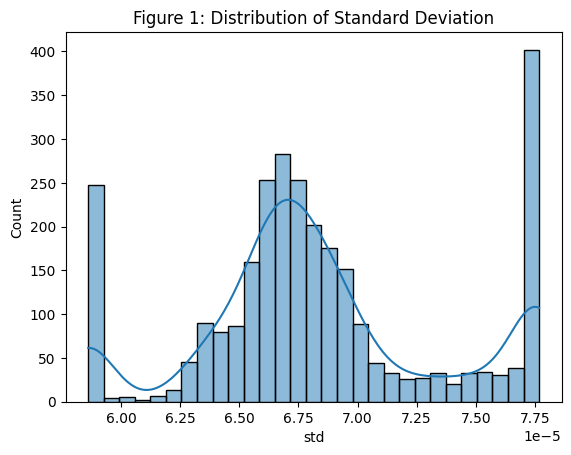

In [16]:
sns.histplot(df_all["std"], kde=True)
plt.title("Figure 1: Distribution of Standard Deviation")
plt.show()

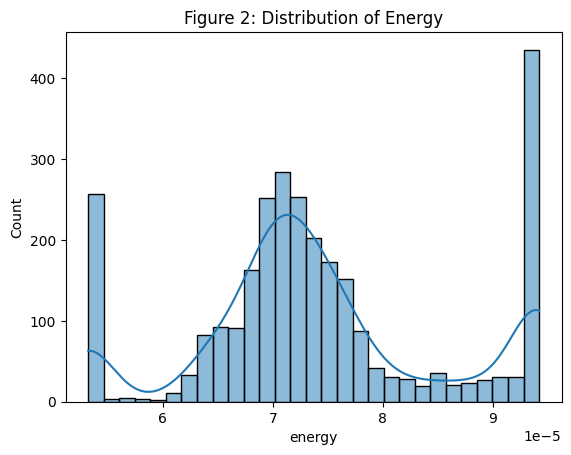

In [19]:
sns.histplot(df_all["energy"], kde=True)
plt.title("Figure 2: Distribution of Energy")
plt.show()

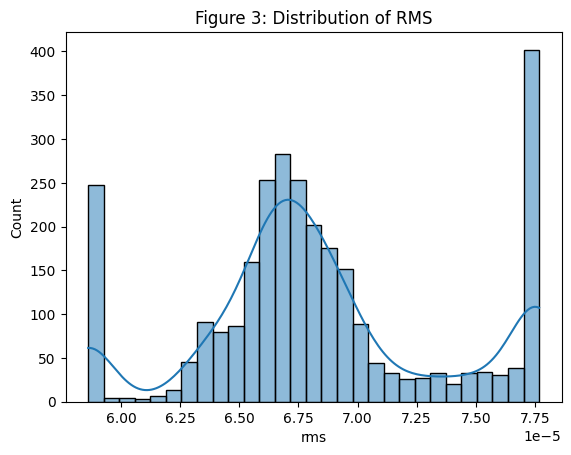

In [20]:
sns.histplot(df_all["rms"], kde=True)
plt.title("Figure 3: Distribution of RMS")
plt.show()

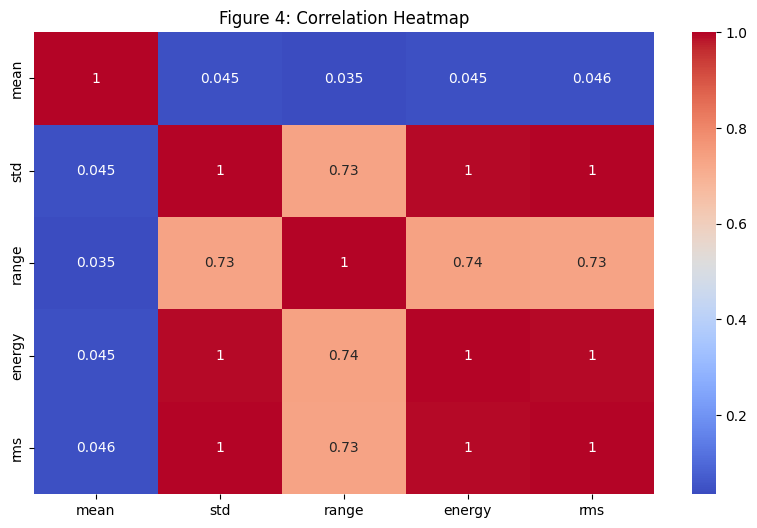

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(df_all[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Figure 4: Correlation Heatmap")
plt.show()

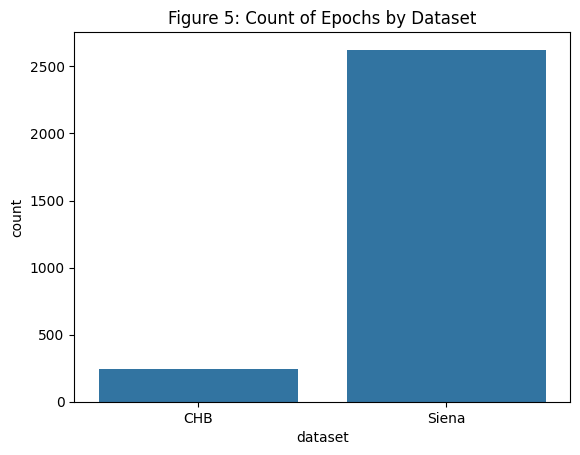

In [22]:
sns.countplot(x="dataset", data=df_all)
plt.title("Figure 5: Count of Epochs by Dataset")
plt.show()

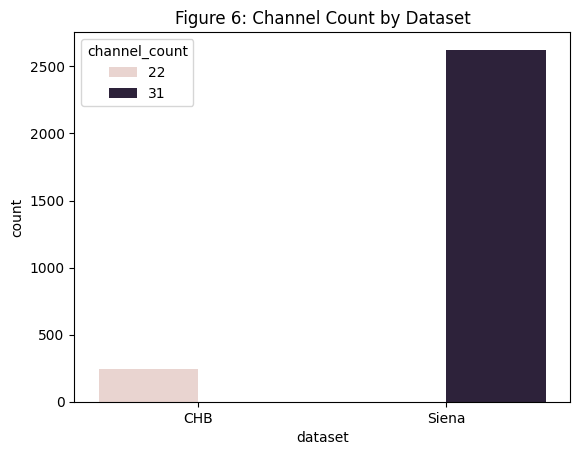

In [23]:
sns.countplot(x="dataset", data=df_all, hue="channel_count")
plt.title("Figure 6: Channel Count by Dataset")
plt.show()

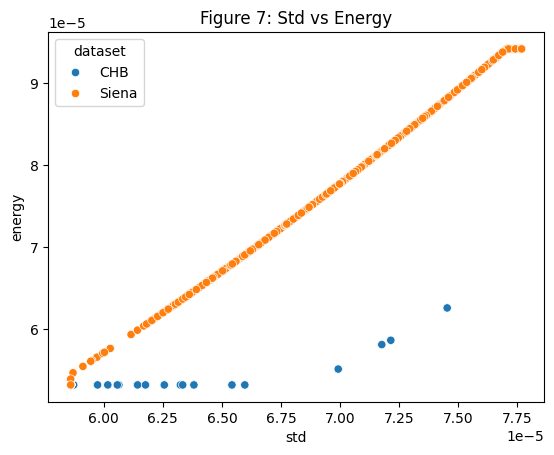

In [24]:
sns.scatterplot(x="std", y="energy", hue="dataset", data=df_all)
plt.title("Figure 7: Std vs Energy")
plt.show()

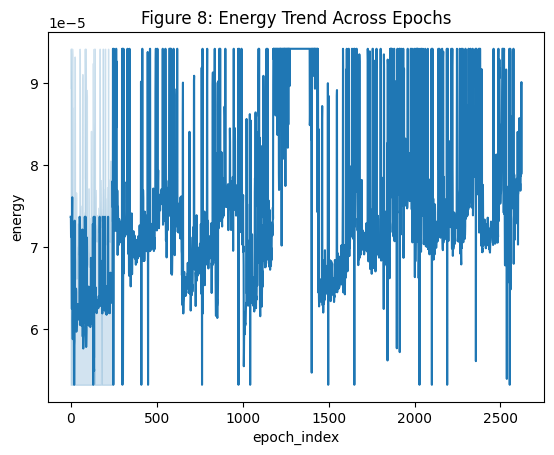

In [25]:
sns.lineplot(x="epoch_index", y="energy", data=df_all, estimator="mean")
plt.title("Figure 8: Energy Trend Across Epochs")
plt.show()